# Parametric source spectra

The `wcc_etc` exposure-time calculator can build a source `SourceSpectrum`
on the fly from a handful of keyword arguments. In addition to Pickles
spectral types and on-disk spectra, `get_scene(name=...)` accepts four
**parametric** source types:

| `name` | params | meaning |
|--------|--------|---------|
| `blackbody` | `teff` (K) | Planck spectrum, normalized to `mag` |
| `flat` | `flat_unit='fnu'` (default, AB-flat) or `'flam'` | constant F_nu or F_lambda |
| `powerlaw` | `alpha`, `lambda_ref=5500` | F_lambda is proportional to (lambda/lambda_ref)^alpha |
| `emission` | `lines=[{wave, flux, fwhm}]`, `mag=None` | sum of Gaussian lines, **absolute** flux (erg/s/cm^2) |

This notebook builds each type through the public `get_scene(...)` entry point,
plots the spectra, checks them against analytic physics (Planck / Wien,
F_nu vs F_lambda, power-law slope, Gaussian line profile, Pogson scaling), and
drives them through the full `Simulation` ETC.


In [1]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import h, c, k_B
from synphot import units as su

import wcc_etc
wcc_etc.set_wcc_style()

# Standard background config reused everywhere.
BKG = {"bandpass": "johnson_r", "mag": 22.5}

def get_source_spectrum(apply_mag=False, **kw):
    """Build a scene via the public get_scene() and return its source SourceSpectrum."""
    kw.setdefault("bandpass", "johnson_r")
    kw.setdefault("background", "zodi")
    kw.setdefault("background_prop", BKG)
    scene = wcc_etc.get_scene(**kw)
    return scene.source.get_spectrum(apply_mag=apply_mag)

def flam(spectrum, wave_AA):
    """F_lambda [erg/s/cm^2/A] at the given wavelength(s) in Angstrom."""
    return spectrum(np.asarray(wave_AA) * u.AA, flux_unit=su.FLAM).value

w = np.arange(3500, 9500, 2.0)   # plotting grid [Angstrom]
print("wcc_etc loaded")

wcc_etc loaded


## 1. Blackbody -- Planck shape and Wien's law

`name='blackbody', teff=<K>` builds a `BlackBodyNorm1D` normalized to the
requested broadband magnitude. We overlay a few temperatures (peak-normalized
shape, `apply_mag=False`) and mark Wien's displacement-law peak
lambda_max = 2.8977719e7 / T (Angstrom). We then check the peak location and the
Planck flux ratio against the analytic Planck function (astropy constants).


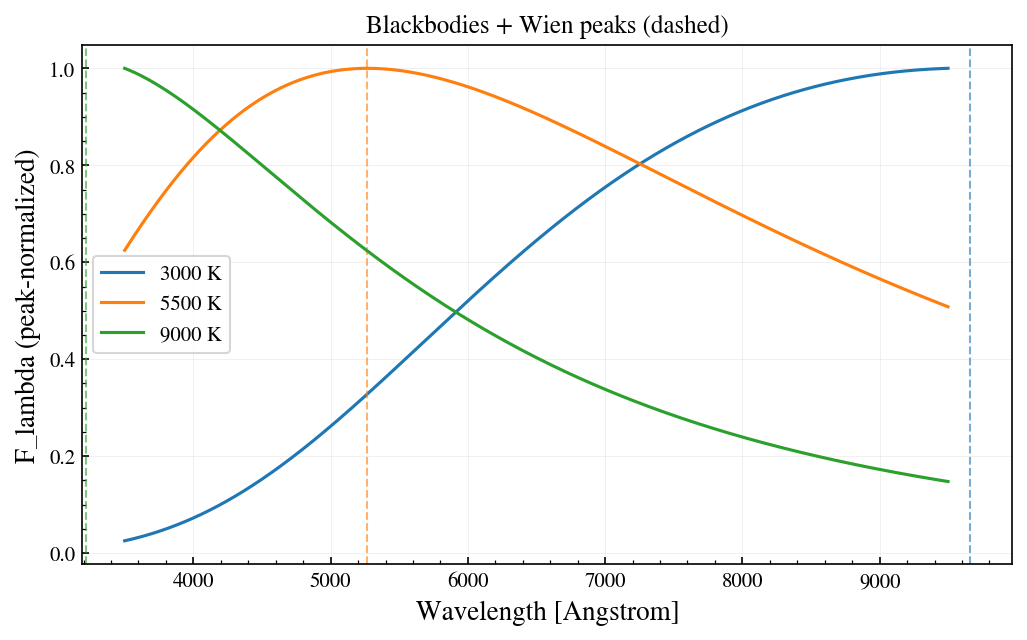

Wien peak (T=5500 K):           model 5268 A   expected 5269 A
Planck ratio F(4500)/F(7500):  model 1.2224   analytic 1.2224
OK: blackbody matches Planck / Wien


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for teff in [3000, 5500, 9000]:
    sp = get_source_spectrum(name="blackbody", teff=teff, mag=15)
    f = flam(sp, w)
    line, = ax.plot(w, f / f.max(), label=f"{teff} K")
    lam_wien = 2.8977719e7 / teff
    ax.axvline(lam_wien, color=line.get_color(), ls="--", lw=1, alpha=0.6)
ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("F_lambda (peak-normalized)")
ax.set_title("Blackbodies + Wien peaks (dashed)")
ax.legend()
plt.show()

# analytic Planck (per unit wavelength), constants from astropy
def planck_lambda(lam_AA, T):
    lam = (np.asarray(lam_AA) * u.AA).to(u.m).value
    return 1.0 / lam**5 / np.expm1((h.value * c.value) / (lam * k_B.value * T))

T = 5500
sp = get_source_spectrum(name="blackbody", teff=T, mag=15)
wf = np.arange(2000, 30000, 2.0)
peak = wf[np.argmax(flam(sp, wf))]
wien = 2.8977719e7 / T
ratio_model = flam(sp, 4500) / flam(sp, 7500)
ratio_analytic = planck_lambda(4500, T) / planck_lambda(7500, T)
print(f"Wien peak (T={T} K):           model {peak:.0f} A   expected {wien:.0f} A")
print(f"Planck ratio F(4500)/F(7500):  model {ratio_model:.4f}   analytic {ratio_analytic:.4f}")
assert abs(peak - wien) < 50,            "blackbody peak should match Wien's law"
assert abs(ratio_model / ratio_analytic - 1) < 0.01, "Planck shape should match analytic"
print("OK: blackbody matches Planck / Wien")


## 2. Flat -- constant F_nu vs constant F_lambda

`name='flat'` defaults to `flat_unit='fnu'`: flat in F_nu (the AB reference),
which falls as lambda^-2 in F_lambda. `flat_unit='flam'` is flat in F_lambda.
The check confirms the AB-flat source obeys F_lambda(l1)/F_lambda(l2) = (l2/l1)^2.


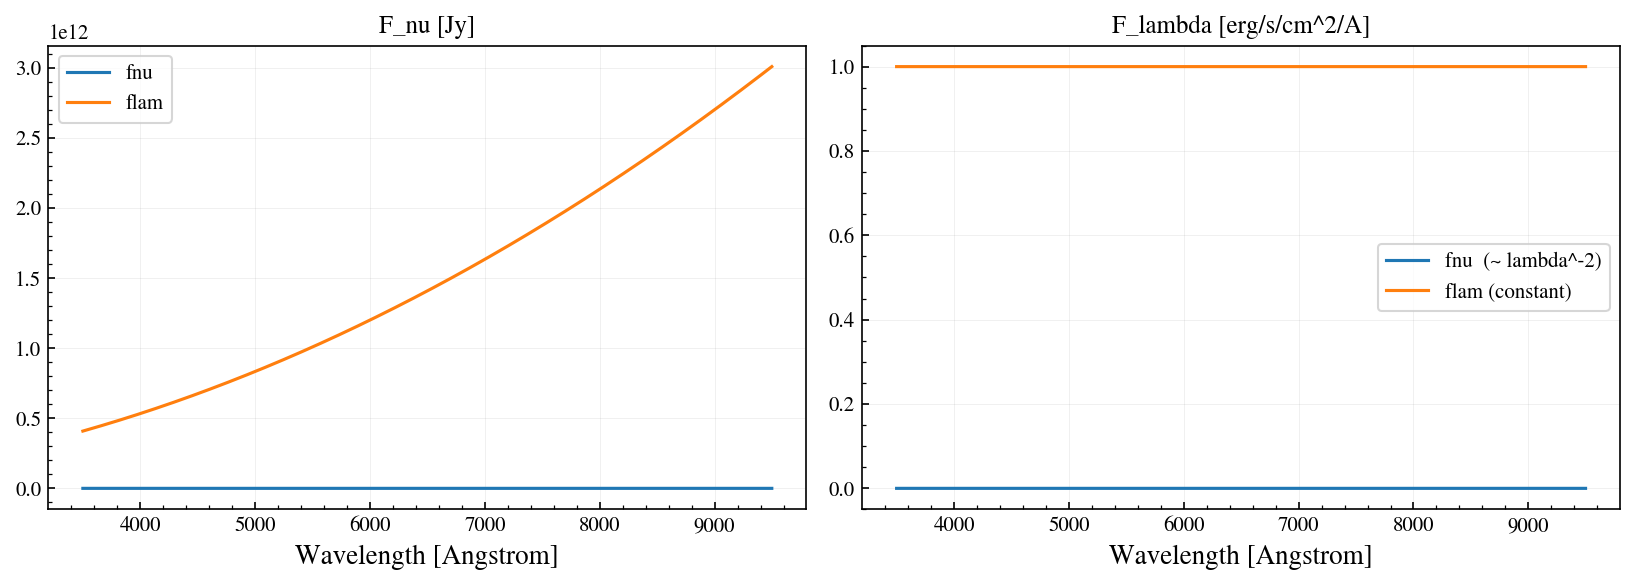

flat(fnu): F_lambda ratio 4.0000   expected (l2/l1)^2 = 4.0000
OK: AB-flat is flat in F_nu (lambda^-2 in F_lambda)


In [3]:
sp_fnu  = get_source_spectrum(name="flat", flat_unit="fnu",  mag=15)
sp_flam = get_source_spectrum(name="flat", flat_unit="flam", mag=15)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(w, sp_fnu(w * u.AA, flux_unit=u.Jy).value,  label="fnu")
a1.plot(w, sp_flam(w * u.AA, flux_unit=u.Jy).value, label="flam")
a1.set_title("F_nu [Jy]"); a1.set_xlabel("Wavelength [Angstrom]"); a1.legend()
a2.plot(w, flam(sp_fnu, w),  label="fnu  (~ lambda^-2)")
a2.plot(w, flam(sp_flam, w), label="flam (constant)")
a2.set_title("F_lambda [erg/s/cm^2/A]"); a2.set_xlabel("Wavelength [Angstrom]"); a2.legend()
fig.tight_layout(); plt.show()

l1, l2 = 4000.0, 8000.0
ratio = flam(sp_fnu, l1) / flam(sp_fnu, l2)
print(f"flat(fnu): F_lambda ratio {ratio:.4f}   expected (l2/l1)^2 = {(l2 / l1) ** 2:.4f}")
assert abs(ratio / (l2 / l1) ** 2 - 1) < 0.01, "AB-flat F_lambda should fall as lambda^-2"
print("OK: AB-flat is flat in F_nu (lambda^-2 in F_lambda)")


## 3. Power law -- F_lambda proportional to lambda^alpha

`name='powerlaw', alpha=<exponent>` builds F_lambda ~ (lambda/lambda_ref)^alpha
(`alpha=0` is flat in F_lambda; negative alpha is red, positive is blue).
The public `alpha` is the F_lambda exponent. We check the flux ratio matches
(4500/7500)^alpha.


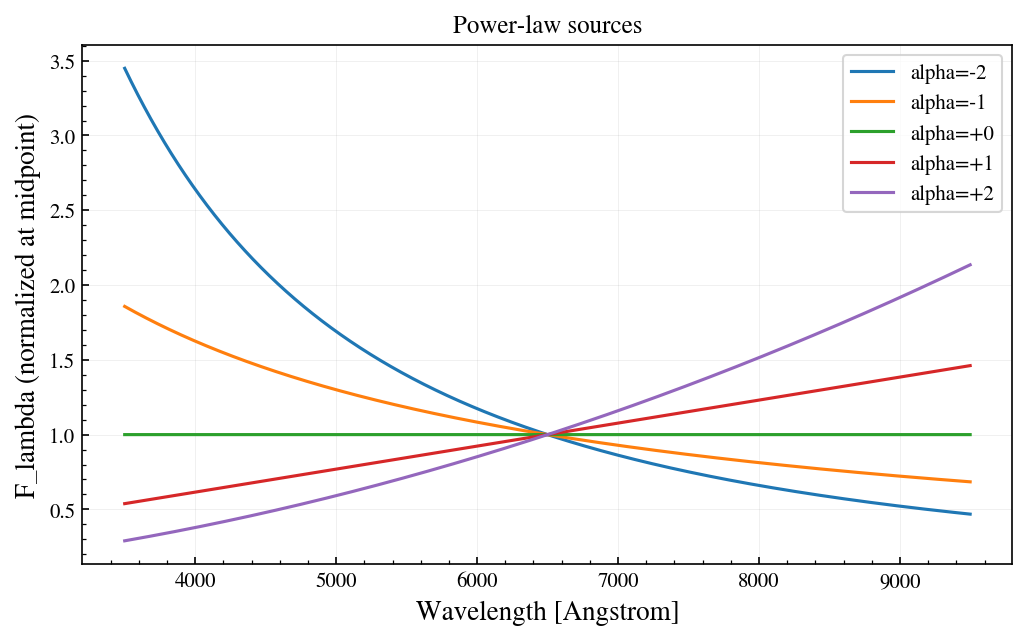

Power-law slope check: F(4500)/F(7500)
  alpha=-2.0:  model 2.7778   expected 2.7778
  alpha=-1.0:  model 1.6667   expected 1.6667
  alpha=+0.0:  model 1.0000   expected 1.0000
  alpha=+1.5:  model 0.4648   expected 0.4648
OK: F_lambda follows lambda^alpha


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for alpha in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    sp = get_source_spectrum(name="powerlaw", alpha=alpha, mag=15)
    f = flam(sp, w)
    ax.plot(w, f / f[len(f) // 2], label=f"alpha={alpha:+.0f}")
ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("F_lambda (normalized at midpoint)")
ax.set_title("Power-law sources")
ax.legend()
plt.show()

print("Power-law slope check: F(4500)/F(7500)")
for alpha in [-2.0, -1.0, 0.0, 1.5]:
    sp = get_source_spectrum(name="powerlaw", alpha=alpha, mag=15)
    r = flam(sp, 4500.0) / flam(sp, 7500.0)
    exp = (4500.0 / 7500.0) ** alpha
    print(f"  alpha={alpha:+.1f}:  model {r:.4f}   expected {exp:.4f}")
    assert abs(r / exp - 1) < 0.01, "power-law slope should match lambda^alpha"
print("OK: F_lambda follows lambda^alpha")


## 4. Emission lines -- absolute integrated flux

`name='emission', mag=None, lines=[{wave, flux, fwhm}]` builds a sum of
`GaussianFlux1D` profiles where `flux` is the **absolute** integrated line flux
(erg/s/cm^2) and `fwhm` defaults to 2 Angstrom. With `mag=None` the source is
absolute-flux (no broadband normalization). We recover the integrated flux per
line, the FWHM, and the line ratio, comparing the profile peak to an analytic
Gaussian (peak = flux / (fwhm * sqrt(pi / (4 ln 2)))).


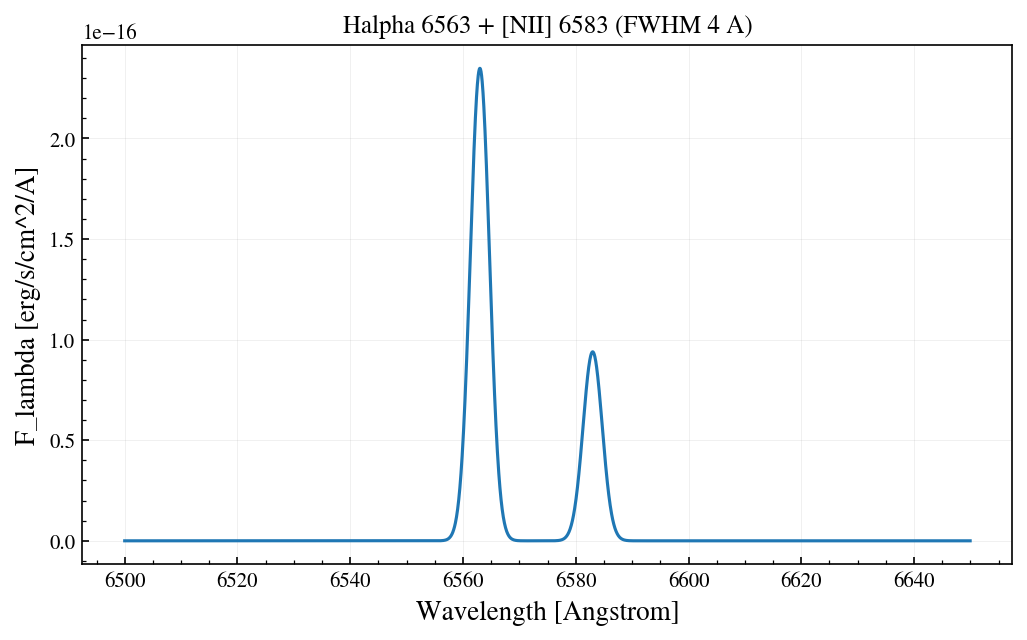

Halpha integrated flux: 1.000e-15   (input 1.0e-15)
[NII]  integrated flux: 4.000e-16   (input 4.0e-16)
Halpha/[NII] ratio:     2.500   (input 2.5)
Halpha peak:  model 2.349e-16   analytic 2.349e-16
Halpha FWHM:  measured 3.98 A   input 4.00 A
OK: emission lines match Gaussian profile / flux / ratio


In [5]:
lines = [{"wave": 6563, "flux": 1e-15, "fwhm": 4},   # Halpha
         {"wave": 6583, "flux": 4e-16, "fwhm": 4}]   # [NII]
sp = get_source_spectrum(name="emission", mag=None, lines=lines)

wl = np.arange(6500, 6650, 0.05)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(wl, flam(sp, wl))
ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("F_lambda [erg/s/cm^2/A]")
ax.set_title("Halpha 6563 + [NII] 6583 (FWHM 4 A)")
plt.show()

# integrated flux per line (lines well separated -> split at 6573)
wa = np.arange(6545, 6573, 0.02); wb = np.arange(6573, 6601, 0.02)
fa = np.trapz(flam(sp, wa), wa)
fb = np.trapz(flam(sp, wb), wb)
print(f"Halpha integrated flux: {fa:.3e}   (input 1.0e-15)")
print(f"[NII]  integrated flux: {fb:.3e}   (input 4.0e-16)")
print(f"Halpha/[NII] ratio:     {fa / fb:.3f}   (input 2.5)")
assert abs(fa / 1e-15 - 1) < 0.02, "Halpha integrated flux should match input"
assert abs(fb / 4e-16 - 1) < 0.02, "[NII] integrated flux should match input"
assert abs(fa / fb / 2.5 - 1) < 0.02, "line ratio should match input"

# peak amplitude and FWHM vs analytic Gaussian for Halpha
fwhm = 4.0
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
peak_analytic = 1e-15 / (sigma * np.sqrt(2 * np.pi))
peak_model = flam(sp, 6563)
# measured FWHM from the sampled profile (Halpha only window)
ha = flam(sp, wa)
half = ha.max() / 2
above = wa[ha >= half]
fwhm_meas = above.max() - above.min()
print(f"Halpha peak:  model {peak_model:.3e}   analytic {peak_analytic:.3e}")
print(f"Halpha FWHM:  measured {fwhm_meas:.2f} A   input {fwhm:.2f} A")
assert abs(peak_model / peak_analytic - 1) < 0.05, "peak should match analytic Gaussian"
assert abs(fwhm_meas - fwhm) < 0.15, "measured FWHM should match input"
print("OK: emission lines match Gaussian profile / flux / ratio")


## 5. Driving the ETC -- SNR vs magnitude (Pogson scaling)

Each continuum source feeds the full `Simulation` through a broadband filter
(`sony:r`). We sweep source magnitude and plot SNR @ 60 s, then check the
Pogson relation: 5 mag fainter implies a 100x lower source count rate.
(Narrowband filters `sony:halpha/nii/oiii/heii` lack throughput files, so
emission sources can't yet be observed; we use the broadband filter here.)


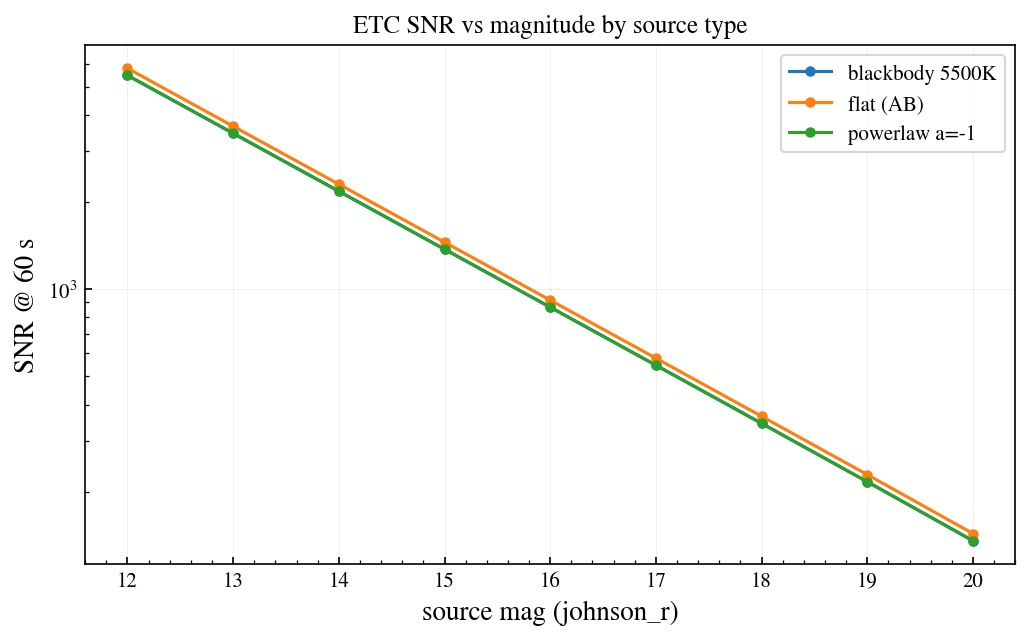

Pogson check (5 mag fainter -> ~100x lower source count rate):


  blackbody 5500K  count-rate ratio = 100.00   (expected ~100)


  flat (AB)        count-rate ratio = 100.00   (expected ~100)


  powerlaw a=-1    count-rate ratio = 100.00   (expected ~100)
OK: source count rate follows Pogson 100x / 5 mag


In [6]:
def make_scene(name, mag, **extra):
    return wcc_etc.get_scene(name=name, mag=mag, host=None, background="zodi",
                             bandpass="johnson_r", background_prop=BKG, **extra)

specs = {"blackbody 5500K": ("blackbody", {"teff": 5500}),
         "flat (AB)":       ("flat", {}),
         "powerlaw a=-1":   ("powerlaw", {"alpha": -1.0})}

mags = np.linspace(12, 20, 9)
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, (name, extra) in specs.items():
    snr = [float(wcc_etc.Simulation.from_sensor_and_scene("sony:r",
                  make_scene(name, m, **extra)).get_snr(60).value) for m in mags]
    ax.plot(mags, snr, "o-", ms=4, label=label)
ax.set_yscale("log")
ax.set_xlabel("source mag (johnson_r)")
ax.set_ylabel("SNR @ 60 s")
ax.set_title("ETC SNR vs magnitude by source type")
ax.legend()
plt.show()

print("Pogson check (5 mag fainter -> ~100x lower source count rate):")
for label, (name, extra) in specs.items():
    cr = []
    for m in (15, 20):
        sim = wcc_etc.Simulation.from_sensor_and_scene("sony:r", make_scene(name, m, **extra))
        cr.append(sim.get_countrates(units="e/s")["source"].value)
    ratio = cr[0] / cr[1]
    print(f"  {label:16s} count-rate ratio = {ratio:6.2f}   (expected ~100)")
    assert abs(ratio / 100 - 1) < 0.02, "Pogson: 5 mag -> 100x count rate"
print("OK: source count rate follows Pogson 100x / 5 mag")


## 6. `update()` rebuilds the spectrum (type is locked)

Type-appropriate **shape** parameters can be changed in place and rebuild the
spectrum, which changes the SNR. The spectrum **type** is locked:
`sim.update(source__spectrum=...)` is ignored (with a warning).


In [7]:
scene = make_scene("blackbody", 15, teff=8000)
sim = wcc_etc.Simulation.from_sensor_and_scene("sony:r", scene)
snr_hot = sim.get_snr(60).value
print(f"SNR teff=8000:                 {snr_hot:.1f}")

sim.update(source__teff=3000)          # cooler blackbody -> less r-band flux
snr_cool = sim.get_snr(60).value
print(f"SNR teff=3000 (after update):  {snr_cool:.1f}")
assert snr_cool != snr_hot, "update(source__teff) should change SNR"
print(f"SNR changed by update(): {snr_hot:.1f} -> {snr_cool:.1f}")

# the spectrum TYPE is locked
with warnings.catch_warnings(record=True) as rec:
    warnings.simplefilter("always")
    sim.update(source__spectrum="powerlaw")
msgs = [str(wmsg.message) for wmsg in rec]
print("source__spectrum update ignored:", msgs)
assert any("ignored" in m for m in msgs), "changing the spectrum type should be rejected"
print("OK: shape params update in place; spectrum type is locked")


SNR teff=8000:                 1461.0
SNR teff=3000 (after update):  1130.1
SNR changed by update(): 1461.0 -> 1130.1
source__spectrum update ignored: ["no entries found matiching key='source__spectrum'. *key='source__spectrum' ignored*"]
OK: shape params update in place; spectrum type is locked


## Summary

All four parametric source types build correctly through `get_scene(name=...)`,
match analytic physics, and drive the ETC:

- **blackbody** -- peak follows Wien's law; F_lambda ratio matches the analytic Planck function.
- **flat** -- AB-flat (`fnu`) falls as lambda^-2 in F_lambda; `flam` is constant.
- **powerlaw** -- F_lambda follows (lambda/lambda_ref)^alpha.
- **emission** -- absolute integrated line flux, FWHM, and line ratio recovered against a Gaussian.
- **ETC** -- SNR vs magnitude follows Pogson (100x count rate per 5 mag).
- **update()** -- type-appropriate shape parameters rebuild the spectrum in place and change the SNR,
  while the spectrum type stays locked.

See `tests/test_source_physics.py` and `tests/test_scene.py` for the automated versions of these checks.
